# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

Before evaluating individual signals, it is important to understand how the main variables are distributed.

The following visualizations help identify whether the variables are normally distributed or have heavy tails. Heavy-tailed distributions indicate that a small number of pages contribute disproportionately large values, which should be considered when designing ranking rules or machine learning models.

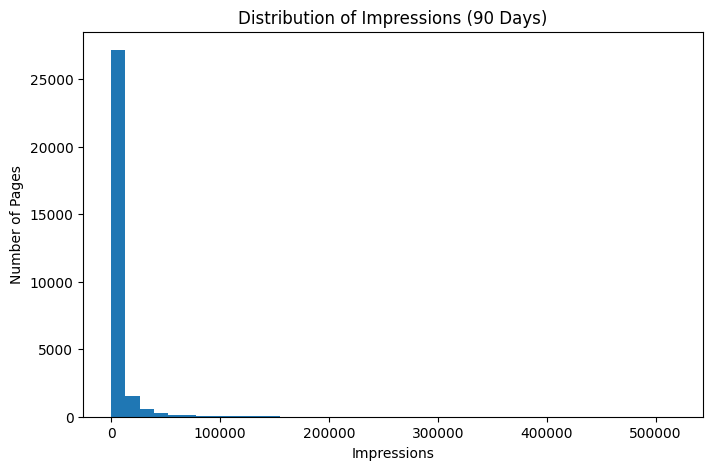

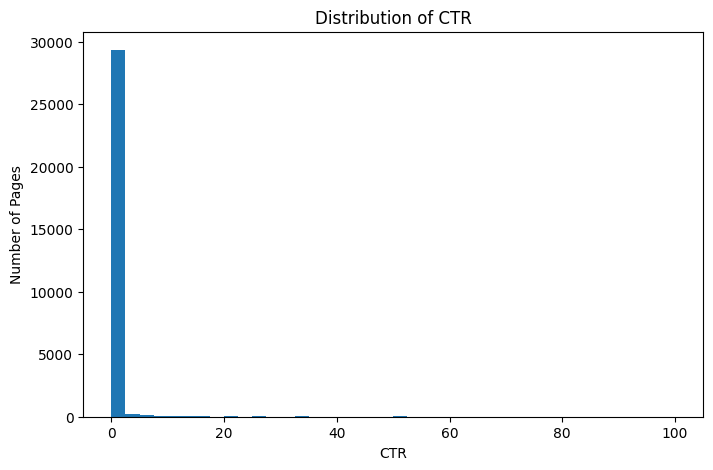

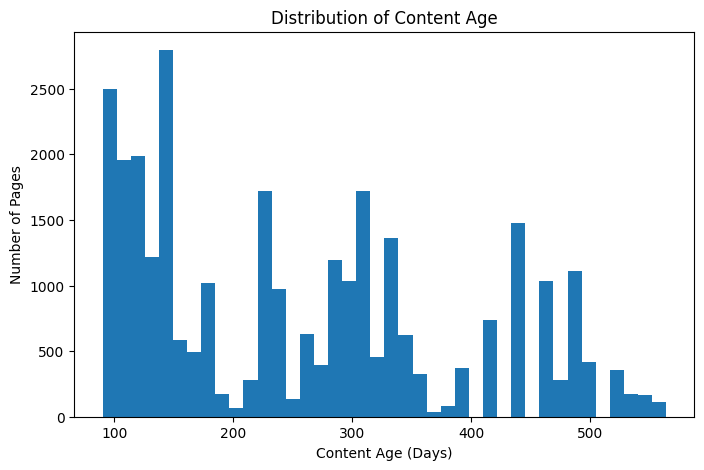

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

plt.figure(figsize=(8,5))
plt.hist(df["impressions_90d"], bins=40)
plt.title("Distribution of Impressions (90 Days)")
plt.xlabel("Impressions")
plt.ylabel("Number of Pages")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["ctr"], bins=40)
plt.title("Distribution of CTR")
plt.xlabel("CTR")
plt.ylabel("Number of Pages")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["content_age_days"], bins=40)
plt.title("Distribution of Content Age")
plt.xlabel("Content Age (Days)")
plt.ylabel("Number of Pages")
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*
## Signal Test 1

### Signal

Older content is more likely to decline.

### Verdict

Directional / Mixed

In [4]:
age = df.groupby("trend_direction")["content_age_days"].median()

print(age)

trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        291.5
Name: content_age_days, dtype: float64


## Signal Test 2

### Signal

Pages with better search positions receive higher CTR.

### Verdict

Confirmed

position_tier
deep        0.150212
page_1      0.652467
page_3_5    0.222484
striking    0.323239
top_3       1.483611
Name: ctr, dtype: float64


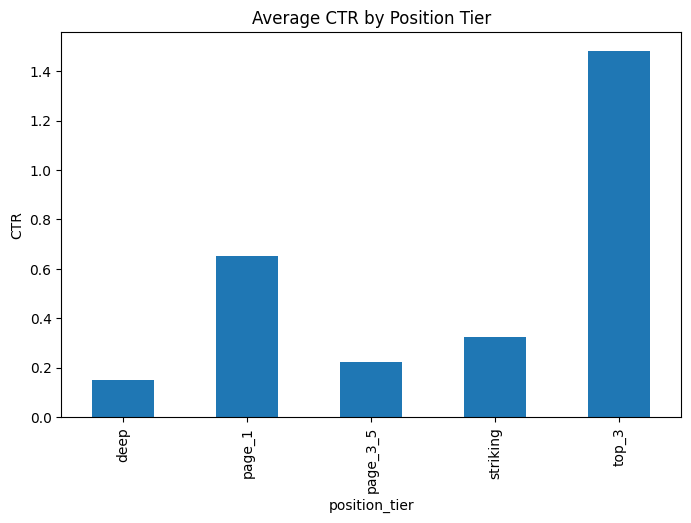

In [5]:
ctr = df.groupby("position_tier")["ctr"].mean()

print(ctr)

plt.figure(figsize=(8,5))
ctr.plot(kind="bar")
plt.title("Average CTR by Position Tier")
plt.ylabel("CTR")
plt.show()

## Signal Test 3

### Signal

Pages with higher search volume receive more impressions.

### Verdict

Mixed

In [6]:
corr = df["search_volume"].corr(df["impressions_90d"])

print("Correlation:", corr)

Correlation: 0.0012030310696208905


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

One refresh signal assumes that pages which have not been updated for a long time but still receive traffic are strong candidates for review.

The following test checks whether pages with larger values of days_since_last_update also receive meaningful impressions.

In [8]:
stale = df[df["days_since_last_update"] >= 180]

print("Pages older than 180 days:", len(stale))
print()

print("Average Impressions:")
print(round(stale["impressions_90d"].mean(),2))

print()

print("Median Impressions:")
print(round(stale["impressions_90d"].median(),2))

Pages older than 180 days: 174

Average Impressions:
1172.45

Median Impressions:
15.5


## 4. What this means in practice
## Practical Meaning

The analysis suggests that individual metrics should not be used in isolation.

Content age, CTR, impressions, and search position together provide better evidence than any single feature.

These observations should be used as decision-support rather than definitive proof of content quality or future performance.

## Self-check

Before you submit, confirm each line honestly:

- [✅ ] Every section above is filled — markdown thinking AND the code that backs it
- [✅ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅ ] No client names, URLs, or private queries anywhere
- [✅ ] My claims use careful words: observed, measured, directional, decision-support
- [✅ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.